# K-Means Clustering on Monsters Dataset

This notebook implements the **K-Means clustering algorithm from scratch** (without using sklearn's KMeans) on the Monsters dataset. The dataset contains 15 monster vectors described by 6 features:
- **Warmth** – body color "warmer" or "colder"
- **Eyes** – number of eyes
- **Feet** – number of feet
- **Teeth** – number of teeth
- **Solid** – whether the monster is solid in coloring (1) or not (0)
- **Wings** – whether the monster has wings (or appendages) (1) or not (0)

K-Means partitions the data into **k clusters** by iteratively assigning each data point to the ***nearest centroid and recomputing centroids until convergence***.

## Step 1: Configure Parameters

Set the value of **k** (number of clusters) here. The default is `k = 3`. You can change this to any integer between 1 and the number of data points.

In [ ]:
# ============================================================
# USER INPUT: Set the number of clusters (k) here
# ============================================================
K = 3          # <-- Change this value to experiment with different k
RANDOM_SEED = 42   # For reproducible centroid initialization
MAX_ITERATIONS = 100  # Maximum number of iterations before stopping

print(f"K-Means will run with k = {K} clusters")

K-Means will run with k = 3 clusters


## Step 2: Import Libraries

We use only **NumPy** for computation, **Pandas** for loading the data, and **Matplotlib** for visualization. The K-Means algorithm itself is implemented from scratch.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

np.random.seed(RANDOM_SEED)
print("Libraries loaded successfully.")

Libraries loaded successfully.


## Step 3: Load and Inspect the Data

We load the CSV file and inspect its shape, features, and summary statistics to understand what we're clustering.

In [ ]:
# Load the dataset
df = pd.read_csv('/home/Monsters_Data.csv')

print(f"Dataset shape: {df.shape[0]} monsters × {df.shape[1]} features")
print(f"\nFeature columns: {list(df.columns)}")
print("\n--- Full Dataset ---")
print(df.to_string())
print("\n--- Summary Statistics ---")
print(df.describe().round(2))

Dataset shape: 15 monsters × 6 features

Feature columns: ['Warmth', 'Eyes', 'Feet', 'Teeth', 'Solid', 'Wings']

--- Full Dataset ---
    Warmth  Eyes  Feet  Teeth  Solid  Wings
0        1     2     3      2      1      0
1        2     2     0      2      1      0
2        2     3     2      0      0      0
3       -1     1     2      0      0      0
4       -2     1     2      1      0      1
5       -2     3     3      2      0      0
6       -1     2     2      3      0      0
7       -1     2     2      0      0      1
8       -2     2     4      1      0      0
9       -1     1     0      3      1      0
10       1     2     3      3      0      0
11       0     3     2      0      0      1
12       2     4     3      2      0      0
13       0     4     2      0      0      0
14      -1     4     2      1      1      1

--- Summary Statistics ---
       Warmth   Eyes   Feet  Teeth  Solid  Wings
count   15.00  15.00  15.00  15.00  15.00  15.00
mean    -0.20   2.40   2.13   1.33  

## Step 4: Prepare the Data Matrix

Convert the DataFrame to a NumPy array `X` of shape `(n_samples, n_features)`. Each row is a monster vector.

In [ ]:
X = df.values.astype(float)
feature_names = list(df.columns)
n_samples, n_features = X.shape

print(f"Data matrix X has shape: {X.shape}")
print(f"  - {n_samples} monster vectors")
print(f"  - {n_features} features per vector: {feature_names}")

Data matrix X has shape: (15, 6)
  - 15 monster vectors
  - 6 features per vector: ['Warmth', 'Eyes', 'Feet', 'Teeth', 'Solid', 'Wings']


## Step 5: Implement K-Means from Scratch

The K-Means algorithm works as follows:

1. **Initialize** k centroids by randomly selecting k data points.
2. **Assignment step**: Assign each data point to the nearest centroid using Euclidean distance.
3. **Update step**: Recompute each centroid as the mean of all points assigned to it.
4. **Repeat** steps 2–3 until centroids no longer change (convergence) or `MAX_ITERATIONS` is reached.

The functions below implement each part of this process.

In [ ]:
def euclidean_distance(point, centroid):
    """
    Compute the Euclidean distance between a single data point and a centroid.

    Euclidean distance = sqrt( sum( (x_i - c_i)^2 ) )
    """
    return np.sqrt(np.sum((point - centroid) ** 2))


def initialize_centroids(X, k, seed=42):
    """
    Initialize k centroids by randomly sampling k data points from X.
    This is the 'Forgy' initialization method.
    """
    np.random.seed(seed)
    indices = np.random.choice(len(X), size=k, replace=False)
    return X[indices].copy()


def assign_clusters(X, centroids):
    """
    Assign each data point in X to the nearest centroid.

    Returns an array of cluster labels (0 to k-1) for each point.
    """
    labels = []
    for point in X:
        distances = [euclidean_distance(point, c) for c in centroids]
        labels.append(np.argmin(distances))  # Index of the closest centroid
    return np.array(labels)


def update_centroids(X, labels, k):
    """
    Recompute centroids as the mean of all points assigned to each cluster.

    If a cluster has no points assigned, re-initialize its centroid randomly
    to avoid 'dead' clusters.
    """
    new_centroids = []
    for cluster_id in range(k):
        cluster_points = X[labels == cluster_id]
        if len(cluster_points) == 0:
            # Edge case: empty cluster — reinitialize with a random point
            new_centroids.append(X[np.random.randint(0, len(X))])
        else:
            new_centroids.append(cluster_points.mean(axis=0))
    return np.array(new_centroids)


def kmeans(X, k, max_iter=100, seed=42):
    """
    Full K-Means algorithm.

    Parameters:
        X        : data matrix (n_samples, n_features)
        k        : number of clusters
        max_iter : maximum number of iterations
        seed     : random seed for reproducibility

    Returns:
        labels    : cluster assignment for each data point
        centroids : final centroid positions
        history   : list of centroid positions at each iteration (for visualization)
        n_iter    : number of iterations until convergence
    """
    centroids = initialize_centroids(X, k, seed)
    history = [centroids.copy()]

    for iteration in range(max_iter):
        labels = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, labels, k)
        history.append(new_centroids.copy())

        # Check for convergence: centroids stopped moving
        if np.allclose(centroids, new_centroids):
            print(f"  Converged after {iteration + 1} iteration(s).")
            return labels, new_centroids, history, iteration + 1

        centroids = new_centroids

    print(f"  Reached maximum iterations ({max_iter}).")
    return labels, centroids, history, max_iter


print("K-Means functions defined successfully.")

K-Means functions defined successfully.


## Step 6: Run the K-Means Algorithm

Run K-Means on the Monsters dataset using the value of `K` set in Step 1.

In [ ]:
print(f"Running K-Means with k = {K}...")
labels, centroids, history, n_iter = kmeans(X, K, max_iter=MAX_ITERATIONS, seed=RANDOM_SEED)

print(f"\nFinal cluster assignments (0-indexed): {labels}")
print(f"Number of iterations to converge: {n_iter}")
print("\nFinal centroid positions:")
centroid_df = pd.DataFrame(centroids, columns=feature_names)
centroid_df.index.name = 'Cluster'
print(centroid_df.round(3).to_string())

Running K-Means with k = 3...
  Converged after 3 iteration(s).

Final cluster assignments (0-indexed): [2 2 2 1 1 1 0 1 1 0 2 1 2 1 1]
Number of iterations to converge: 3

Final centroid positions:
         Warmth  Eyes   Feet  Teeth  Solid  Wings
Cluster                                          
0        -1.000   1.5  1.000  3.000  0.500    0.0
1        -1.125   2.5  2.375  0.625  0.125    0.5
2         1.600   2.6  2.200  1.800  0.400    0.0


## Step 7: Display Cluster Memberships

Print each monster vector alongside its assigned cluster. This answers: **"which vectors belong in which cluster?"**

In [ ]:
# Attach cluster labels to the original dataframe
df_result = df.copy()
df_result['Cluster'] = labels
df_result.index = [f'Monster {i+1}' for i in range(len(df))]

print("=" * 60)
print(f"  CLUSTER ASSIGNMENTS  (k = {K})")
print("=" * 60)
print(df_result.to_string())

print("\n" + "=" * 60)
print("  CLUSTERS SUMMARY")
print("=" * 60)
for cluster_id in range(K):
    members = df_result[df_result['Cluster'] == cluster_id].index.tolist()
    print(f"\nCluster {cluster_id}  ({len(members)} members): {', '.join(members)}")
    print(df_result.loc[members, feature_names].to_string())

  CLUSTER ASSIGNMENTS  (k = 3)
            Warmth  Eyes  Feet  Teeth  Solid  Wings  Cluster
Monster 1        1     2     3      2      1      0        2
Monster 2        2     2     0      2      1      0        2
Monster 3        2     3     2      0      0      0        2
Monster 4       -1     1     2      0      0      0        1
Monster 5       -2     1     2      1      0      1        1
Monster 6       -2     3     3      2      0      0        1
Monster 7       -1     2     2      3      0      0        0
Monster 8       -1     2     2      0      0      1        1
Monster 9       -2     2     4      1      0      0        1
Monster 10      -1     1     0      3      1      0        0
Monster 11       1     2     3      3      0      0        2
Monster 12       0     3     2      0      0      1        1
Monster 13       2     4     3      2      0      0        2
Monster 14       0     4     2      0      0      0        1
Monster 15      -1     4     2      1      1      1   

## Step 8: Visualize the Clusters

Since the data is 6-dimensional, we use two complementary visualizations:

1. **PCA scatter plot** – Reduce to 2D using Principal Component Analysis so we can see cluster separation in a plane.
2. **Parallel coordinates plot** – Show all 6 features simultaneously, colored by cluster, to understand what distinguishes each cluster.
3. **Cluster centroids bar chart** – Compare the mean feature values of each cluster.

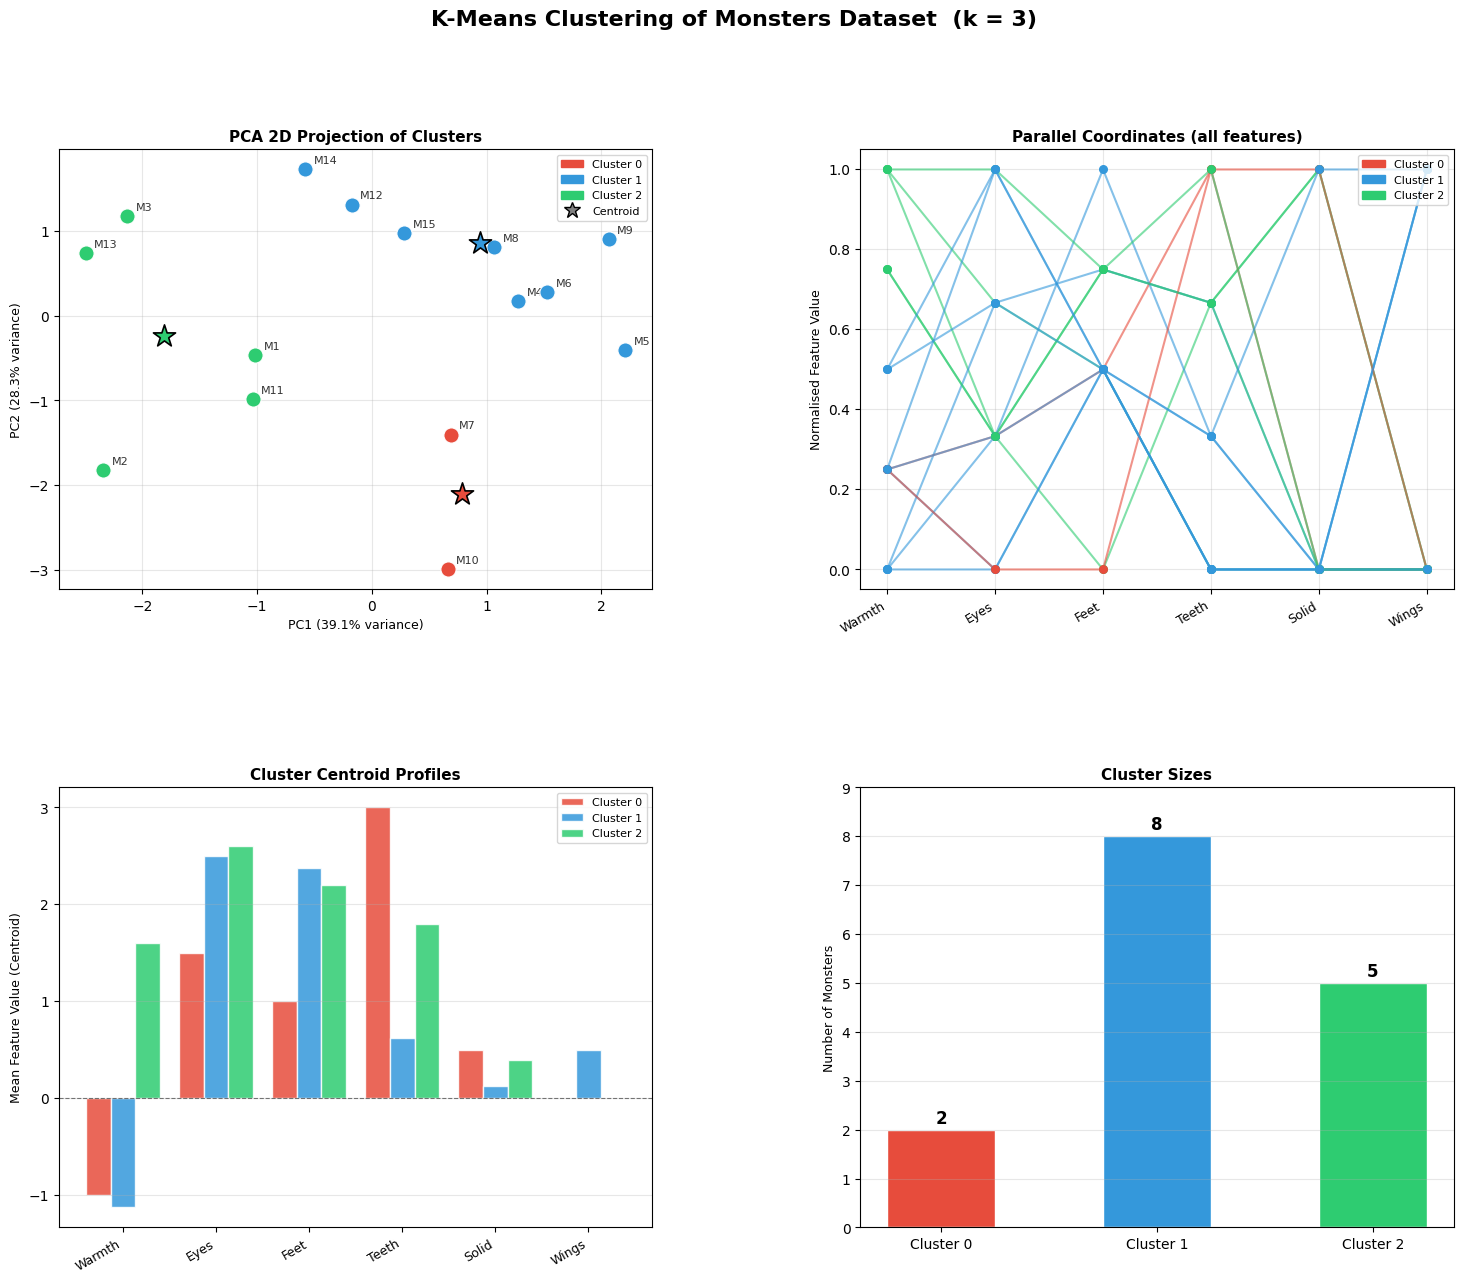

Visualization saved to 'kmeans_monsters_visualization.png'


In [ ]:
# -------------------------------------------------------
# Manual PCA (2D projection) — implemented from scratch
# -------------------------------------------------------
def pca_2d(X):
    """
    Project data onto its first 2 principal components.
    Steps: center data → compute covariance matrix → eigen-decompose → project.
    """
    X_centered = X - X.mean(axis=0)
    cov = np.cov(X_centered.T)
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    # Sort by descending eigenvalue
    idx = np.argsort(eigenvalues)[::-1]
    top2 = eigenvectors[:, idx[:2]]
    X_2d = X_centered @ top2
    variance_explained = eigenvalues[idx[:2]] / eigenvalues.sum() * 100
    return X_2d, variance_explained

X_2d, var_exp = pca_2d(X)
centroids_2d, _ = pca_2d(np.vstack([X, centroids]))
centroids_2d = centroids_2d[-K:]  # Last K rows are projected centroids

# -------------------------------------------------------
# Color palette for clusters
# -------------------------------------------------------
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6', '#1ABC9C']
cluster_colors = [colors[l] for l in labels]

fig = plt.figure(figsize=(18, 14))
fig.suptitle(f'K-Means Clustering of Monsters Dataset  (k = {K})',
             fontsize=16, fontweight='bold', y=0.98)
gs = GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# --- Plot 1: PCA 2D Scatter ---
ax1 = fig.add_subplot(gs[0, 0])
for i, (point, color, lbl) in enumerate(zip(X_2d, cluster_colors, labels)):
    ax1.scatter(point[0], point[1], color=color, s=120, zorder=3, edgecolors='white', linewidths=0.8)
    ax1.annotate(f'M{i+1}', (point[0], point[1]), textcoords='offset points',
                 xytext=(6, 4), fontsize=8, color='#333333')
# Plot centroids
for j, cp in enumerate(centroids_2d):
    ax1.scatter(cp[0], cp[1], color=colors[j], s=280, marker='*',
                edgecolors='black', linewidths=1.2, zorder=5)
legend_handles = [mpatches.Patch(color=colors[i], label=f'Cluster {i}') for i in range(K)]
legend_handles.append(plt.Line2D([0],[0], marker='*', color='w', markerfacecolor='gray',
                                  markersize=12, label='Centroid', markeredgecolor='black'))
ax1.legend(handles=legend_handles, loc='best', fontsize=8)
ax1.set_xlabel(f'PC1 ({var_exp[0]:.1f}% variance)', fontsize=9)
ax1.set_ylabel(f'PC2 ({var_exp[1]:.1f}% variance)', fontsize=9)
ax1.set_title('PCA 2D Projection of Clusters', fontsize=11, fontweight='bold')
ax1.grid(True, alpha=0.3)

# --- Plot 2: Parallel Coordinates ---
ax2 = fig.add_subplot(gs[0, 1])
X_norm = (X - X.min(axis=0)) / (np.ptp(X, axis=0) + 1e-8)  # Normalize 0-1 for display
x_ticks = np.arange(n_features)
for i, (row, color) in enumerate(zip(X_norm, cluster_colors)):
    ax2.plot(x_ticks, row, color=color, alpha=0.6, linewidth=1.5)
    ax2.scatter(x_ticks, row, color=color, s=30, zorder=3)
ax2.set_xticks(x_ticks)
ax2.set_xticklabels(feature_names, rotation=30, ha='right', fontsize=9)
ax2.set_ylabel('Normalised Feature Value', fontsize=9)
ax2.set_title('Parallel Coordinates (all features)', fontsize=11, fontweight='bold')
ax2.legend(handles=legend_handles[:K], loc='upper right', fontsize=8)
ax2.grid(True, alpha=0.3)

# --- Plot 3: Cluster Centroids Bar Chart ---
ax3 = fig.add_subplot(gs[1, 0])
x = np.arange(n_features)
bar_width = 0.8 / K
for i in range(K):
    offset = (i - K/2 + 0.5) * bar_width
    ax3.bar(x + offset, centroids[i], width=bar_width, label=f'Cluster {i}',
            color=colors[i], edgecolor='white', alpha=0.85)
ax3.set_xticks(x)
ax3.set_xticklabels(feature_names, rotation=30, ha='right', fontsize=9)
ax3.set_ylabel('Mean Feature Value (Centroid)', fontsize=9)
ax3.set_title('Cluster Centroid Profiles', fontsize=11, fontweight='bold')
ax3.legend(fontsize=8)
ax3.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax3.grid(True, alpha=0.3, axis='y')

# --- Plot 4: Cluster Size Bar Chart ---
ax4 = fig.add_subplot(gs[1, 1])
cluster_sizes = [np.sum(labels == i) for i in range(K)]
bars = ax4.bar([f'Cluster {i}' for i in range(K)], cluster_sizes,
               color=[colors[i] for i in range(K)], edgecolor='white', width=0.5)
for bar, size in zip(bars, cluster_sizes):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             str(size), ha='center', va='bottom', fontsize=12, fontweight='bold')
ax4.set_ylabel('Number of Monsters', fontsize=9)
ax4.set_title('Cluster Sizes', fontsize=11, fontweight='bold')
ax4.set_ylim(0, max(cluster_sizes) + 1)
ax4.grid(True, alpha=0.3, axis='y')

plt.savefig('kmeans_monsters_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved to 'kmeans_monsters_visualization.png'")

## Step 9: Evaluate Clustering Quality (Inertia)

**Inertia** (also called Within-Cluster Sum of Squares, WCSS) measures how tight the clusters are — the sum of squared distances from each point to its assigned centroid. Lower inertia means more compact clusters.

We also compute the **Elbow Curve** for k = 1 to 8, which helps identify the optimal number of clusters.

Inertia (WCSS) for k = 3: 45.7000
  Converged after 2 iteration(s).
  Converged after 2 iteration(s).
  Converged after 3 iteration(s).
  Converged after 4 iteration(s).
  Converged after 5 iteration(s).
  Converged after 3 iteration(s).
  Converged after 2 iteration(s).
  Converged after 2 iteration(s).


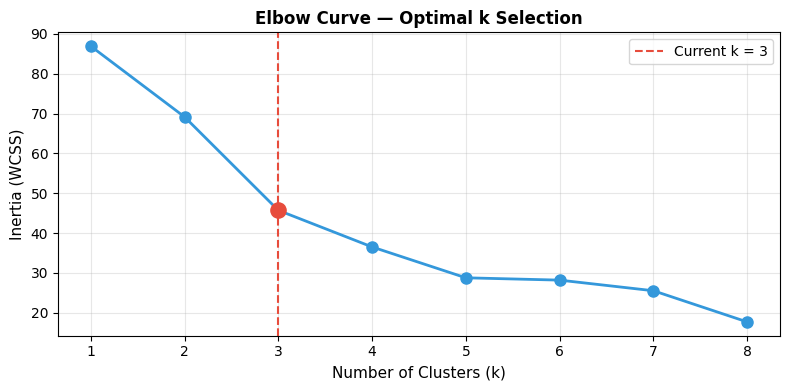

Elbow curve saved to 'elbow_curve.png'


In [ ]:
def compute_inertia(X, labels, centroids):
    """Compute total within-cluster sum of squared distances (inertia)."""
    total = 0.0
    for i, point in enumerate(X):
        centroid = centroids[labels[i]]
        total += np.sum((point - centroid) ** 2)
    return total

# Current inertia
inertia = compute_inertia(X, labels, centroids)
print(f"Inertia (WCSS) for k = {K}: {inertia:.4f}")

# Elbow curve: run K-Means for a range of k values
max_k = min(8, n_samples - 1)
inertia_values = []
k_range = range(1, max_k + 1)

for k_test in k_range:
    lbl, ctr, _, _ = kmeans(X, k_test, max_iter=MAX_ITERATIONS, seed=RANDOM_SEED)
    inertia_values.append(compute_inertia(X, lbl, ctr))

# Plot elbow curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(k_range), inertia_values, 'o-', color='#3498DB', linewidth=2, markersize=8)
ax.axvline(K, color='#E74C3C', linestyle='--', linewidth=1.5, label=f'Current k = {K}')
ax.scatter([K], [inertia_values[K-1]], color='#E74C3C', s=120, zorder=5)
ax.set_xlabel('Number of Clusters (k)', fontsize=11)
ax.set_ylabel('Inertia (WCSS)', fontsize=11)
ax.set_title('Elbow Curve — Optimal k Selection', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('elbow_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Elbow curve saved to 'elbow_curve.png'")

## Step 10: Final Summary

Print a clean, final summary of the clustering results.

In [ ]:
print("=" * 65)
print(f"         K-MEANS CLUSTERING FINAL SUMMARY  (k = {K})")
print("=" * 65)
print(f"  Dataset         : Monsters_Data.csv")
print(f"  Vectors         : {n_samples} monsters × {n_features} features")
print(f"  Clusters (k)    : {K}")
print(f"  Iterations      : {n_iter}")
print(f"  Inertia (WCSS)  : {inertia:.4f}")
print()
print("  Cluster Assignments:")
print("  " + "-" * 55)
for cluster_id in range(K):
    members = [f'M{i+1}' for i in range(n_samples) if labels[i] == cluster_id]
    print(f"  Cluster {cluster_id}  ({len(members):2d} monsters) : {', '.join(members)}")
print()
print("  Centroids (feature means per cluster):")
print("  " + "-" * 55)
print(centroid_df.round(3).to_string(index=True))
print("=" * 65)
print(X_2d)

         K-MEANS CLUSTERING FINAL SUMMARY  (k = 3)
  Dataset         : Monsters_Data.csv
  Vectors         : 15 monsters × 6 features
  Clusters (k)    : 3
  Iterations      : 3
  Inertia (WCSS)  : 45.7000

  Cluster Assignments:
  -------------------------------------------------------
  Cluster 0  ( 2 monsters) : M7, M10
  Cluster 1  ( 8 monsters) : M4, M5, M6, M8, M9, M12, M14, M15
  Cluster 2  ( 5 monsters) : M1, M2, M3, M11, M13

  Centroids (feature means per cluster):
  -------------------------------------------------------
         Warmth  Eyes   Feet  Teeth  Solid  Wings
Cluster                                          
0        -1.000   1.5  1.000  3.000  0.500    0.0
1        -1.125   2.5  2.375  0.625  0.125    0.5
2         1.600   2.6  2.200  1.800  0.400    0.0
[[-1.01817854 -0.46223259]
 [-2.34186794 -1.81666604]
 [-2.13099986  1.1668693 ]
 [ 1.2750559   0.17070498]
 [ 2.21096274 -0.40271259]
 [ 1.53148503  0.27992572]
 [ 0.68689909 -1.40066254]
 [ 1.06556406  0.800640